In [1]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Configuration

log_dirs = ["../raw_data/seams250", "../raw_data/seams500"]
test_runner_log_filename = "test-runner.log"
enforcer_log_filename = "enforcer.log"
asmeta_server_log_filename = "asmeta-server.log"

test_runner_output_filename = "extracted_test_results.csv"
enforcer_output_filename = "extracted_enforcer_data.csv"
asmeta_output_filename = "extracted_asmeta_data.csv"

ping_file = "../raw_data/ping.txt"

log_pattern = re.compile(
    r"Test #(\d+): expected \[(.*?)\], executed \[(.*?)\] \(check: (True|False)\), time: (.*?) ms"
)
enforcer_delay_pattern = re.compile(r"delay\s+([0-9]+(?:\.[0-9]+)?)\s+ms")
asmeta_server_execution_pattern = re.compile(r"Execution time \(in milliseconds\):\s+([0-9]+(?:\.[0-9]+)?)\s+ms")
ping_log_pattern = re.compile(r"time=([\d.]+)\s*ms")

## Test Runner data analysis

In [3]:
# Data extraction and file saving

records = []

for log_dir in log_dirs:
    experiment_id = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, test_runner_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = log_pattern.search(line)
            if match:
                test_case_number = int(match.group(1))

                expected_list = [x.strip().strip("'\"") for x in match.group(2).split(",")]
                executed_list = [x.strip().strip("'\"") for x in match.group(3).split(",")]

                # Reordering executed tasks according to the SLEEC definition (so to match the expected ones)
                # Note: the order of executed tasks from the log is random according to the casual callback execution order
                executed_ordered = [x for x in expected_list if x in executed_list]

                expected_str = " AND ".join(expected_list)
                executed_str = " AND ".join(executed_ordered)
                check_val = match.group(4) == "True"

                time_ms = match.group(5)

                records.append({
                    "experiment_id": experiment_id,
                    "test_case_number": test_case_number,
                    "expected_obligation": expected_str,
                    "executed_obligation": executed_str,
                    "check": check_val,
                    "total_enforcement_time": time_ms
                })

df = pd.DataFrame(records)
df["total_enforcement_time"] = pd.to_numeric(df["total_enforcement_time"], errors="coerce")

df.to_csv(test_runner_output_filename, index=False)
df.head()

,experiment_id,test_case_number,expected_obligation,executed_obligation,check,total_enforcement_time
0,seams250,1,,,True,NaN
1,seams250,2,encourage,encourage,True,100.0
2,seams250,3,greetInUserLanguage AND closeDoor AND startTra...,greetInUserLanguage AND closeDoor AND startTra...,True,97.0
3,seams250,4,wakeUpUser,wakeUpUser,True,90.0
4,seams250,5,encourage,encourage,True,75.0


## Result consistency check

In [4]:
mask_invalid = ~((df["expected_obligation"] == df["executed_obligation"]) & (df["check"] == True))
invalid_rows = df[mask_invalid]

print(f"Number of rows that do NOT satisfy the consistency requirement: {len(invalid_rows)}")
if not invalid_rows.empty:
    display(invalid_rows)
else:
    print("All rows satisfy: expected_obligation == executed_obligation and check == True")

Number of rows that do NOT satisfy the consistency requirement: 0
All rows satisfy: expected_obligation == executed_obligation and check == True


## Overhead data analysis

In [5]:
# Dataset cleaning

mask = df["total_enforcement_time"] < 4
replaced_count = int(mask.sum())
df.loc[mask, "total_enforcement_time"] = float("nan")

print(f"Replaced {replaced_count} entries with NaN.")

Replaced 37 entries with NaN.


In [6]:
# Analysis of enforcement time

stats = df["total_enforcement_time"].describe()
print("Stats for the total enforcement time:")
print(stats)

print("\nMeasures:")
print(f"Median: {df['total_enforcement_time'].median()}")
print(f"Variance: {df['total_enforcement_time'].var()}")
print(f"Number of NaN (when no obligation needed to be enforced): {df['total_enforcement_time'].count()}")

print("\nStats for experiment ID:")
print(df.groupby("experiment_id")["total_enforcement_time"].describe())

Stats for the total enforcement time:
count    594.000000
mean      76.121212
std        5.718122
min       63.000000
25%       72.000000
50%       75.000000
75%       79.000000
max      104.000000
Name: total_enforcement_time, dtype: float64

Measures:
Median: 75.0
Variance: 32.696918595738126
Number of NaN (when no obligation needed to be enforced): 594

Stats for experiment ID:
               count       mean       std   min   25%   50%    75%    max
experiment_id                                                            
seams250       198.0  76.707071  5.706444  63.0  73.0  76.5  79.75  100.0
seams500       396.0  75.828283  5.708604  65.0  72.0  75.0  79.00  104.0


## Enforcer data analysis

In [7]:
enforcer_iteration_records = []

for log_dir in log_dirs:
    experiment = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, enforcer_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = enforcer_delay_pattern.search(line)
            if match:
                delay_value = float(match.group(1))
                enforcer_iteration_records.append({
                    "experiment": experiment,
                    "delay_ms": delay_value
                })

df_enforcer_overhead = pd.DataFrame(enforcer_iteration_records)

if not df_enforcer_overhead.empty:
    stats = df_enforcer_overhead.groupby("experiment")["delay_ms"].describe()

    stats["variance"] = df_enforcer_overhead.groupby("experiment")["delay_ms"].var()
    stats["median"] = df_enforcer_overhead.groupby("experiment")["delay_ms"].median()

    # Overall (all data without grouping)
    overall = df_enforcer_overhead["delay_ms"].describe()
    overall["variance"] = df_enforcer_overhead["delay_ms"].var()
    overall["median"] = df_enforcer_overhead["delay_ms"].median()
    stats.loc["all"] = overall

    print("Stats for the enforcer delay:")
    display(stats)

    stats.to_csv(enforcer_output_filename)

Stats for the enforcer delay:


,count,mean,std,min,25%,50%,75%,max,variance,median
experiment,,,,,,,,,,
seams250,1915.0,43.911593,7.215524,36.25,41.415,43.10,45.19,296.98,52.063791,43.10
seams500,3910.0,43.451072,4.673706,35.49,41.010,42.78,45.02,200.18,21.843531,42.78
all,5825.0,43.602470,5.640760,35.49,41.140,42.90,45.08,296.98,31.818179,42.90


## ASMETA Server data analysis

In [8]:
asmeta_enforcement_records = []

for log_dir in log_dirs:
    experiment = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, asmeta_server_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = asmeta_server_execution_pattern.search(line)
            if match:
                delay_value = float(match.group(1))
                asmeta_enforcement_records.append({
                    "experiment": experiment,
                    "delay_ms": delay_value
                })

df_asmeta_overhead = pd.DataFrame(asmeta_enforcement_records)

if not df_asmeta_overhead.empty:
    stats = df_asmeta_overhead.groupby("experiment")["delay_ms"].describe()

    stats["variance"] = df_asmeta_overhead.groupby("experiment")["delay_ms"].var()
    stats["median"] = df_asmeta_overhead.groupby("experiment")["delay_ms"].median()

    # Overall (all data without grouping)
    overall = df_asmeta_overhead["delay_ms"].describe()
    overall["variance"] = df_asmeta_overhead["delay_ms"].var()
    overall["median"] = df_asmeta_overhead["delay_ms"].median()
    stats.loc["all"] = overall

    print("Stats for the asmeta delay:")
    display(stats)

    stats.to_csv(asmeta_output_filename)

Stats for the asmeta delay:


,count,mean,std,min,25%,50%,75%,max,variance,median
experiment,,,,,,,,,,
seams250,1982.0,1.752775,2.155591,1.0,1.0,1.0,2.0,64.0,4.646572,1.0
seams500,5825.0,1.648755,1.506360,1.0,1.0,1.0,2.0,64.0,2.269120,1.0
all,7807.0,1.675163,1.695354,1.0,1.0,1.0,2.0,64.0,2.874227,1.0


## Data reporting

In [9]:
asmeta_mean = df_asmeta_overhead["delay_ms"].mean() if not df_asmeta_overhead.empty else float("nan")
enforcer_mean = df_enforcer_overhead["delay_ms"].mean() if not df_enforcer_overhead.empty else float("nan")
test_runner_mean = df["total_enforcement_time"].mean()

labels = ["Overall", "Enforcer", "ASMeta server"]
values = [test_runner_mean, enforcer_mean, asmeta_mean]


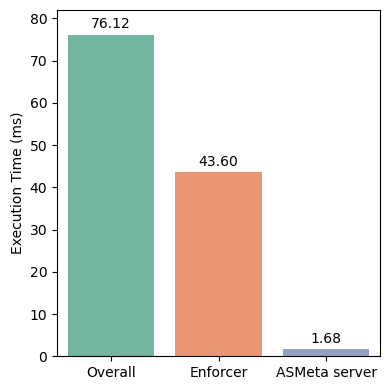

In [10]:

df_plot = pd.DataFrame({
    "component": labels,
    "time": values
})

# sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(4, 4))
ax = sns.barplot(data=df_plot, x="component", y="time", hue="component", palette='Set2')

# Aggiungi etichette sopra le barre
for i, v in enumerate(values):
    ax.text(i, v + (max(values) * 0.02), f"{v:.2f}", ha='center')

ax.set_ylim(0, 82)

plt.xlabel("")
plt.ylabel("Execution Time (ms)")
plt.tight_layout()

plt.show()

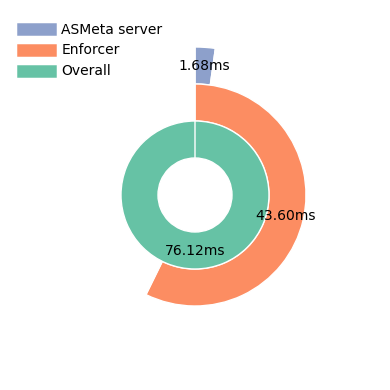

In [11]:
norm_values = [v / test_runner_mean for v in values]

out_to_in_norm_values = list(reversed(norm_values))
out_to_in_values = list(reversed(values))
out_to_in_labels = list(reversed(labels))

colors = sns.color_palette("Set2", len(values))
colors.reverse()


fig, ax = plt.subplots(figsize=(4, 4), subplot_kw=dict(aspect="equal"))

base_radius = 1.0
ring_width = 0.25

# From outer to inner ring
for i, (label, value, color) in enumerate(zip(out_to_in_labels, out_to_in_norm_values, colors)):
    radius = base_radius - i * ring_width

    ax.pie(
        [value, 1 - value],
        radius=radius,
        colors=[color, "white"],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=ring_width, edgecolor="white")
    )

    # Label position
    angle = (90 - value * 360 / 2) * np.pi / 180
    x = np.cos(angle) * (radius - ring_width / 2)
    y = np.sin(angle) * (radius - ring_width / 2)

    # Text
    ax.text(
        x,
        y,
        # f"{out_to_in_labels[i]} ({out_to_in_values[i]:.2f}ms)",
        f"{out_to_in_values[i]:.2f}ms",
        ha="center",
        va="center",
        fontsize=10,
        # fontweight="bold",
        color="black"
    )

handles = [plt.Line2D([0], [0], color=c, lw=9) for c in colors]
ax.legend(handles, out_to_in_labels, loc="upper left", fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

## Ping analysis

In [12]:
ping_path = os.path.join(ping_file)

if not os.path.exists(ping_path):
    print(f"File not found: {ping_path}")

else:
    ping_records = []
    with open(ping_path, "r", encoding="utf-8") as f:
        for line in f:
            match = ping_log_pattern.search(line)
            if match:
                time_value = float(match.group(1))
                ping_records.append({
                    "time": time_value
                })

    df_ping = pd.DataFrame(ping_records)

    if not df_ping.empty:
        stats = df_ping["time"].describe()

        stats["variance"] = df_ping["time"].var()
        stats["median"] = df_ping["time"].median()

        print("Ping data stats:")
        display(stats)

Ping data stats:


count       65.000000
mean         3.464769
std          1.576651
min          1.770000
25%          2.590000
50%          3.160000
75%          3.680000
max          9.690000
variance     2.485828
median       3.160000
Name: time, dtype: float64